In [29]:
import os, math, random
from pathlib import Path
 
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import pickle
import timm
import splitfolders

In [30]:
RUN_PHASE = 2

In [31]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

In [32]:
DATASET_DIR    = Path("dataset")
TRAIN_ORIGINAL = DATASET_DIR / "train"
NUM_CLASSES    = len([d for d in TRAIN_ORIGINAL.iterdir() if d.is_dir()])
print(f"Classes found: {NUM_CLASSES}")

Classes found: 4


In [33]:
class config:
    ROOT_DIR  = Path("content")
    TRAIN_DIR = ROOT_DIR / "train"
    VAL_DIR   = ROOT_DIR / "val"
    TEST_DIR  = DATASET_DIR / "test"
 
    INPUT_SIZE  = 224
    BATCH_SIZE  = 64
    NUM_CLASSES = NUM_CLASSES
    DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
 
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]
 
    LR           = 3e-4
    WEIGHT_DECAY = 0.05
    MAX_EPOCHS   = 60
    PATIENCE     = 10
    LABEL_SMOOTH = 0.1
 
    CKPT_DIR      = Path("checkpoints")
    BEST_CKPT     = CKPT_DIR / "best_vit.pth"
    AVG_CKPT      = CKPT_DIR / "avg_vit.pth"
    HISTORY_FILE  = CKPT_DIR / "phase1_history.pkl"   # persists history across runs
 
config.CKPT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Device : {config.DEVICE}  |  Phase: {RUN_PHASE}")
print(f"Classes: {config.NUM_CLASSES}")

Device : cuda  |  Phase: 2
Classes: 4


In [34]:
if not config.ROOT_DIR.exists():
    print("Splitting 90/10 ...")
    splitfolders.ratio(
        str(TRAIN_ORIGINAL), output=str(config.ROOT_DIR),
        seed=SEED, ratio=(0.9, 0.1), group_prefix=None, move=False
    )
    print("Split done.")
else:
    print(f"'{config.ROOT_DIR}' exists — skipping split.")

'content' exists — skipping split.


In [35]:
class_names = sorted([d.name for d in config.TRAIN_DIR.iterdir() if d.is_dir()])
print("Classes:", class_names)

Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']


In [36]:
class GrayscaleToRGB:
    """Picklable L→RGB — lambdas can't be pickled on Windows spawn workers."""
    def __call__(self, img):
        return img.convert("RGB")
 
grayscale_to_rgb = GrayscaleToRGB()
 
train_transforms = transforms.Compose([
    grayscale_to_rgb,
    transforms.Resize((config.INPUT_SIZE + 16, config.INPUT_SIZE + 16)),
    transforms.RandomCrop(config.INPUT_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.MEAN, std=config.STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.10)),
])
 
val_test_transforms = transforms.Compose([
    grayscale_to_rgb,
    transforms.Resize((config.INPUT_SIZE, config.INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.MEAN, std=config.STD),
])

In [37]:
train_set = datasets.ImageFolder(str(config.TRAIN_DIR), transform=train_transforms)
val_set   = datasets.ImageFolder(str(config.VAL_DIR),   transform=val_test_transforms)
test_set  = datasets.ImageFolder(str(config.TEST_DIR),  transform=val_test_transforms)
 
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
 
train_loader = DataLoader(train_set, batch_size=config.BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
 

Train: 9216 | Val: 1024 | Test: 1279


In [38]:
UNFREEZE_BLOCKS = 4
 
def build_model(pretrained=True):
    m = timm.create_model(
        "vit_small_patch16_224",
        pretrained=pretrained,
        num_classes=config.NUM_CLASSES,
    )
    return m
 
def freeze_for_phase1(m):
    for param in m.parameters():
        param.requires_grad = False
    for block in m.blocks[-UNFREEZE_BLOCKS:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in m.norm.parameters():
        param.requires_grad = True
    for param in m.head.parameters():
        param.requires_grad = True

In [39]:
class EMA:
    def __init__(self, model, decay=0.9998):
        self.decay  = decay
        self.shadow = {k: v.clone().float().cpu() for k, v in model.state_dict().items()}
 
    def update(self, model):
        with torch.no_grad():
            for k, v in model.state_dict().items():
                self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v.float().cpu()
 
    def apply(self, model):
        model.load_state_dict({k: v.to(config.DEVICE) for k, v in self.shadow.items()})

In [40]:
def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
 
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images = images.to(config.DEVICE, non_blocking=True)
            labels = labels.to(config.DEVICE, non_blocking=True)
 
            if train:
                optimizer.zero_grad(set_to_none=True)
 
            with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):
                outputs = model(images)
                loss    = criterion(outputs, labels)
 
            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                ema.update(model)
 
            total_loss += loss.item() * labels.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
 
    return total_loss / total, correct / total

In [41]:
def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
 
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images = images.to(config.DEVICE, non_blocking=True)
            labels = labels.to(config.DEVICE, non_blocking=True)
 
            if train:
                optimizer.zero_grad(set_to_none=True)
 
            with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):
                outputs = model(images)
                loss    = criterion(outputs, labels)
 
            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                ema.update(model)
 
            total_loss += loss.item() * labels.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
 
    return total_loss / total, correct / total
 

Loaded Phase 1: 60 epochs, best val=85.16%

PHASE 2 — Full fine-tune (all layers, lr=5e-6)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\1031690652.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(config.BEST_CKPT, map_loca

FT  1/15 | tr_loss=0.5409 tr_acc=0.9040 | vl_loss=0.5953 vl_acc=0.8545
  ✔ New best: 0.8545
FT  2/15 | tr_loss=0.5329 tr_acc=0.9061 | vl_loss=0.5924 vl_acc=0.8594
  ✔ New best: 0.8594
FT  3/15 | tr_loss=0.5161 tr_acc=0.9182 | vl_loss=0.5888 vl_acc=0.8604
  ✔ New best: 0.8604
FT  4/15 | tr_loss=0.4953 tr_acc=0.9275 | vl_loss=0.5853 vl_acc=0.8643
  ✔ New best: 0.8643
FT  5/15 | tr_loss=0.4885 tr_acc=0.9341 | vl_loss=0.5817 vl_acc=0.8662
  ✔ New best: 0.8662
FT  6/15 | tr_loss=0.4754 tr_acc=0.9408 | vl_loss=0.5775 vl_acc=0.8682
  ✔ New best: 0.8682
FT  7/15 | tr_loss=0.4679 tr_acc=0.9465 | vl_loss=0.5736 vl_acc=0.8740
  ✔ New best: 0.8740
FT  8/15 | tr_loss=0.4658 tr_acc=0.9437 | vl_loss=0.5695 vl_acc=0.8740
FT  9/15 | tr_loss=0.4566 tr_acc=0.9512 | vl_loss=0.5654 vl_acc=0.8789
  ✔ New best: 0.8789
FT 10/15 | tr_loss=0.4527 tr_acc=0.9530 | vl_loss=0.5616 vl_acc=0.8809
  ✔ New best: 0.8809
FT 11/15 | tr_loss=0.4502 tr_acc=0.9558 | vl_loss=0.5574 vl_acc=0.8848
  ✔ New best: 0.8848
FT 12/15 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\1031690652.py:173: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(config.AVG_CKPT, map_


  Overall Test Accuracy : 79.91%

Per-class report (weighted avg = key metric — test is imbalanced):
                      precision    recall  f1-score   support

     Mild Impairment     0.5921    0.9162    0.7193       179
 Moderate Impairment     1.0000    0.6667    0.8000        12
       No Impairment     0.8864    0.8172    0.8504       640
Very Mild Impairment     0.8094    0.7299    0.7676       448

            accuracy                         0.7991      1279
           macro avg     0.8220    0.7825    0.7843      1279
        weighted avg     0.8193    0.7991    0.8026      1279



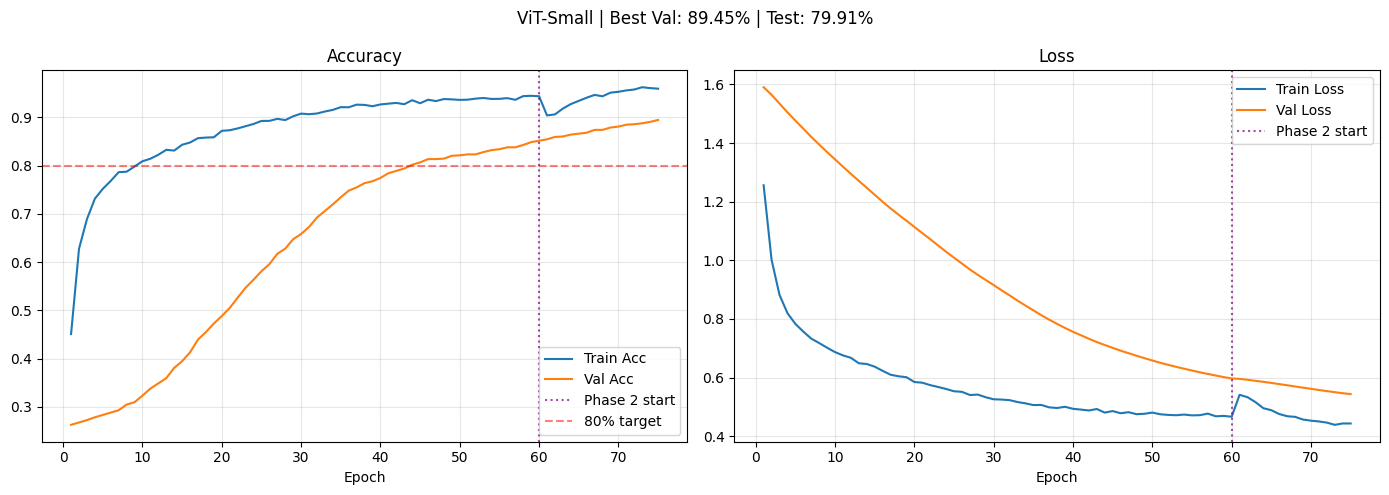

Saved training_curves.png


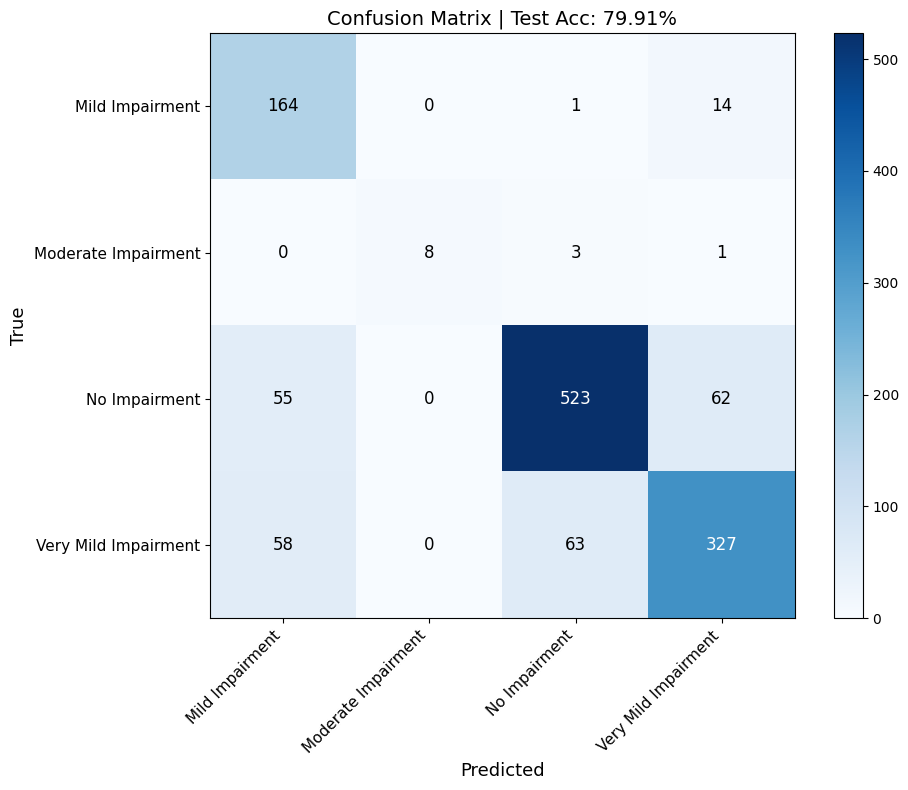

Saved confusion_matrix.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\1031690652.py:262: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):


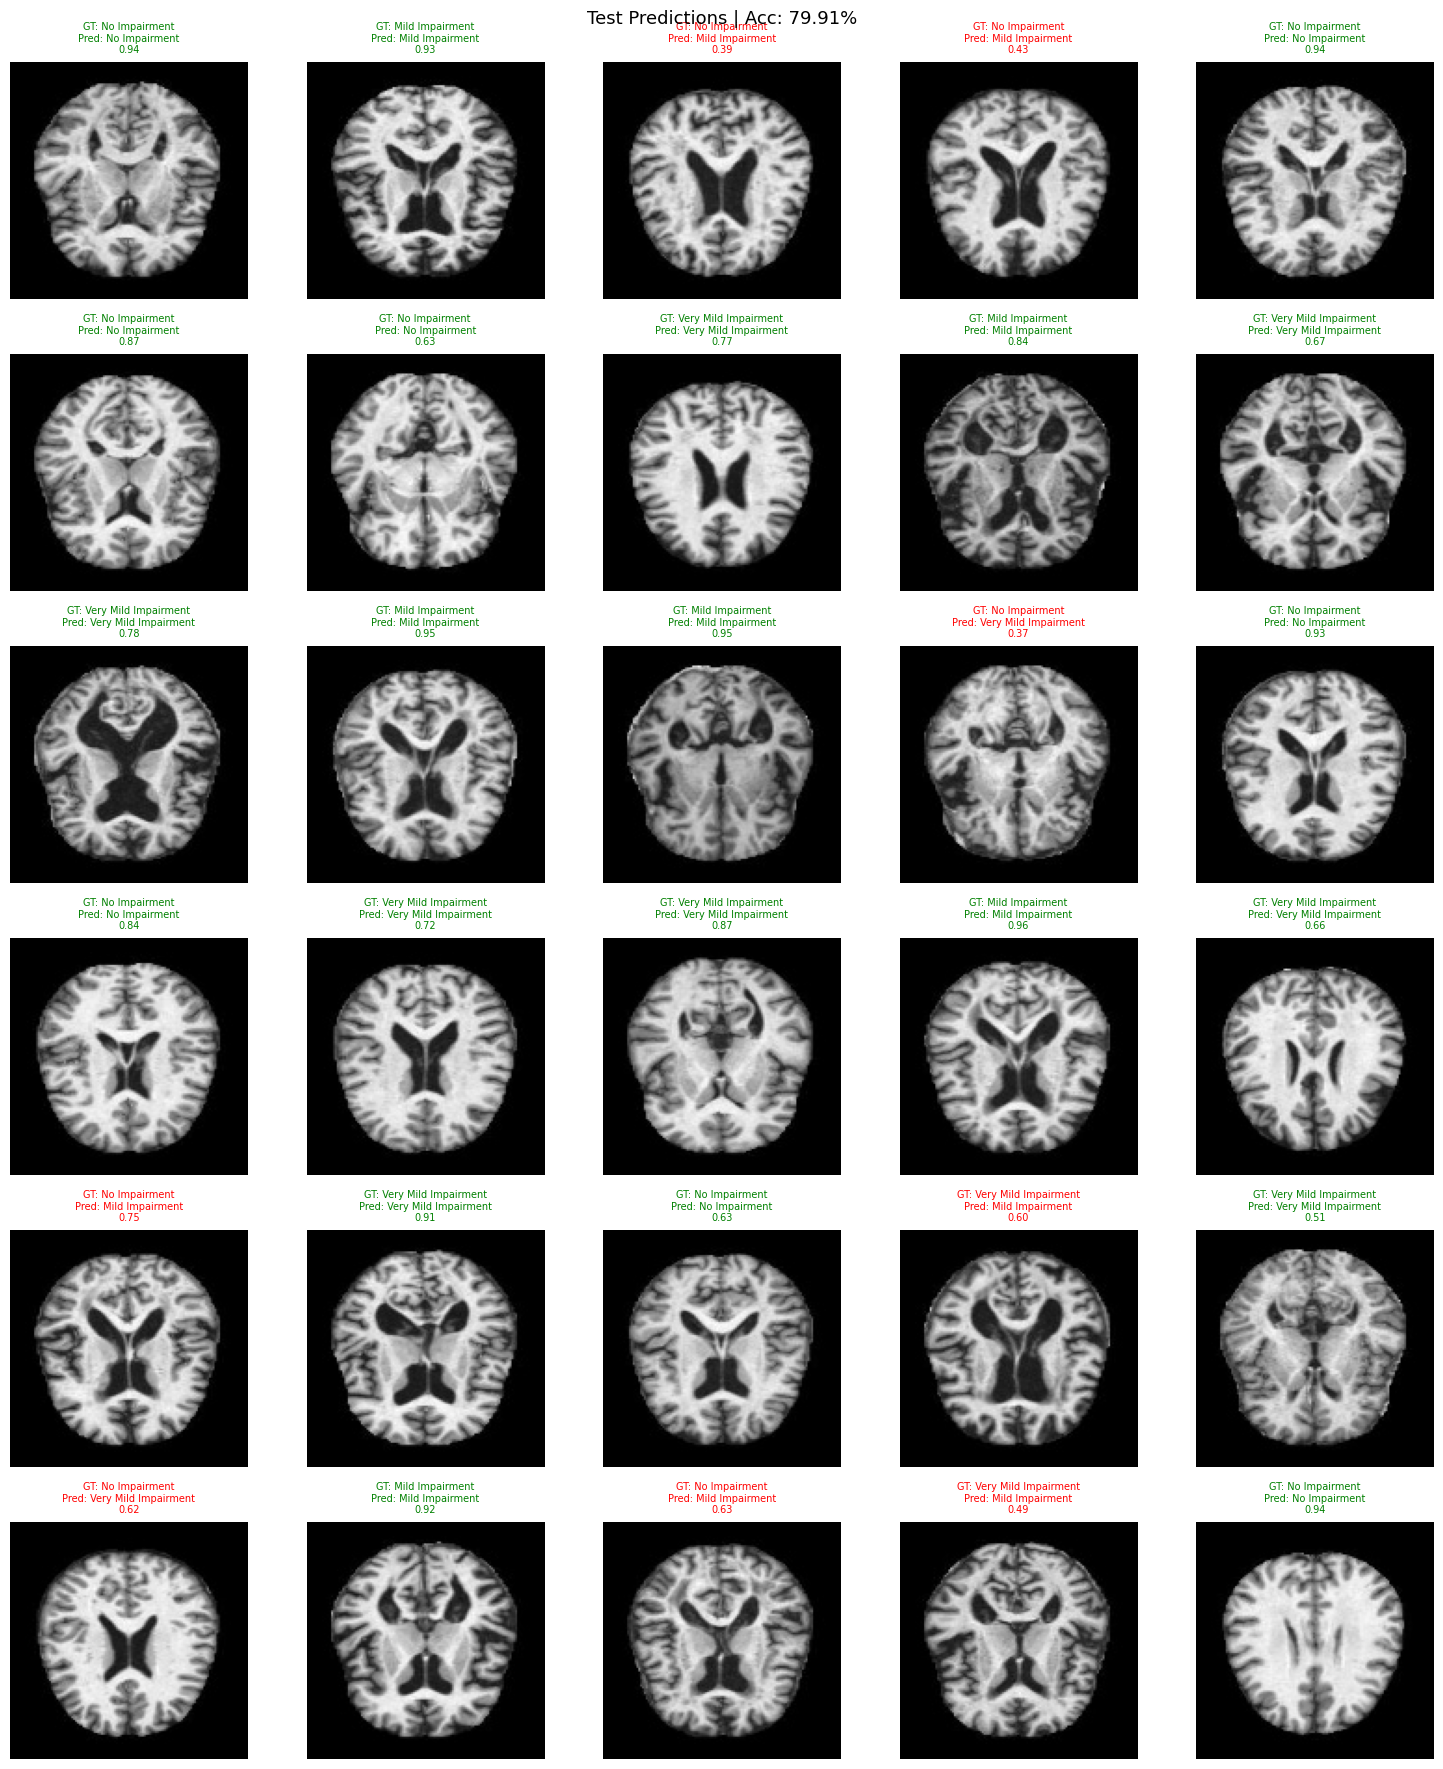

Saved test_predictions.png

All done!


In [42]:
if RUN_PHASE == 1:
    print("\n" + "="*60)
    print(f"PHASE 1 — Last {UNFREEZE_BLOCKS} blocks + head  (blocks 0-7 frozen)")
    print("="*60)
 
    model = build_model(pretrained=True)
    freeze_for_phase1(model)
 
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable:,} / {total_p:,}  ({100*trainable/total_p:.1f}%)")
 
    model = model.to(config.DEVICE)
    if config.DEVICE == "cuda":
        print(f"GPU : {torch.cuda.get_device_name(0)}")
        free, total_mem = torch.cuda.mem_get_info()
        print(f"VRAM: {free/1e9:.1f} GB free / {total_mem/1e9:.1f} GB total")
 
    criterion = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTH)
    optimizer = AdamW([
        {"params": [p for b in model.blocks[-UNFREEZE_BLOCKS:] for p in b.parameters() if p.requires_grad],
         "lr": config.LR * 0.1},
        {"params": list(model.norm.parameters()) + list(model.head.parameters()),
         "lr": config.LR},
    ], weight_decay=config.WEIGHT_DECAY)
 
    steps_per_epoch = len(train_loader)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=[config.LR * 0.1, config.LR],
        steps_per_epoch=steps_per_epoch,
        epochs=config.MAX_EPOCHS,
        pct_start=0.1, anneal_strategy="cos",
        div_factor=10, final_div_factor=1e3,
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(config.DEVICE == "cuda"))
    ema    = EMA(model)
 
    best_val_acc     = 0.0
    patience_counter = 0
    saved_ckpts      = []
    history          = {"tr_loss": [], "tr_acc": [], "vl_loss": [], "vl_acc": []}
 
    for epoch in range(1, config.MAX_EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(train_loader, train=True)
 
        orig = {k: v.clone() for k, v in model.state_dict().items()}
        ema.apply(model)
        vl_loss, vl_acc = run_epoch(val_loader, train=False)
        model.load_state_dict(orig)
 
        history["tr_loss"].append(tr_loss); history["tr_acc"].append(tr_acc)
        history["vl_loss"].append(vl_loss); history["vl_acc"].append(vl_acc)
 
        print(f"Ep {epoch:3d}/{config.MAX_EPOCHS} | "
              f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | "
              f"vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f}")
 
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            ema.apply(model)
            torch.save(model.state_dict(), config.BEST_CKPT)
            saved_ckpts.append({k: v.clone().cpu() for k, v in model.state_dict().items()})
            model.load_state_dict(orig)
            patience_counter = 0
            print(f"  ✔ Best val acc: {best_val_acc:.4f} — saved.")
        else:
            patience_counter += 1
            if patience_counter >= config.PATIENCE:
                print(f"  Early stop at epoch {epoch}.")
                break
 
    # Save history + metadata so Phase 2 can append to it
    saved_ckpts_trimmed = saved_ckpts[-5:]
    with open(config.HISTORY_FILE, "wb") as f:
        pickle.dump({
            "history":      history,
            "best_val_acc": best_val_acc,
        }, f)

    print(f"Averaging {len(saved_ckpts_trimmed)} checkpoint(s) ...")
    avg_state = {
        k: sum(c[k].float() for c in saved_ckpts_trimmed) / len(saved_ckpts_trimmed)
        for k in saved_ckpts_trimmed[0]
    }
    torch.save(avg_state, config.AVG_CKPT)
 
    print(f"Phase 1 done. Best val acc: {best_val_acc*100:.2f}%")
    print(f"Best ckpt  → {config.BEST_CKPT}")
    print(f"Avg ckpt   → {config.AVG_CKPT}")
    print(f"History    → {config.HISTORY_FILE}")
    print("\nSet RUN_PHASE = 2 and run tomorrow.")
 
# =============================================================================
# 11. PHASE 2 + EVAL + PLOTS
# =============================================================================
elif RUN_PHASE == 2:
 
    # Load Phase 1 state
    assert config.HISTORY_FILE.exists(), \
        f"Phase 1 history not found at {config.HISTORY_FILE}. Run Phase 1 first."
    assert config.BEST_CKPT.exists(), \
        f"Phase 1 checkpoint not found at {config.BEST_CKPT}. Run Phase 1 first."
 
    with open(config.HISTORY_FILE, "rb") as f:
        saved = pickle.load(f)

    history      = saved["history"]
    best_val_acc = saved["best_val_acc"]
    saved_ckpts  = []   # fresh — will accumulate Phase 2 bests only (capped at 5)
    phase1_epochs = len(history["tr_acc"])

    print(f"Loaded Phase 1: {phase1_epochs} epochs, best val={best_val_acc*100:.2f}%")
 
    print("\n" + "="*60)
    print("PHASE 2 — Full fine-tune (all layers, lr=5e-6)")
    print("="*60)
 
    model = build_model(pretrained=False)
    model.load_state_dict(torch.load(config.BEST_CKPT, map_location=config.DEVICE))
    for param in model.parameters():
        param.requires_grad = True
    model = model.to(config.DEVICE)
 
    criterion  = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTH)
    optimizer  = AdamW(model.parameters(), lr=5e-6, weight_decay=config.WEIGHT_DECAY)
    steps_per_epoch = len(train_loader)
    scheduler  = OneCycleLR(
        optimizer, max_lr=5e-6,
        steps_per_epoch=steps_per_epoch, epochs=15,
        pct_start=0.1, anneal_strategy="cos",
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(config.DEVICE == "cuda"))
    ema    = EMA(model, decay=0.9998)
 
    for epoch in range(1, 16):
        tr_loss, tr_acc = run_epoch(train_loader, train=True)
 
        orig = {k: v.clone() for k, v in model.state_dict().items()}
        ema.apply(model)
        vl_loss, vl_acc = run_epoch(val_loader, train=False)
        model.load_state_dict(orig)
 
        history["tr_loss"].append(tr_loss); history["tr_acc"].append(tr_acc)
        history["vl_loss"].append(vl_loss); history["vl_acc"].append(vl_acc)
 
        print(f"FT {epoch:2d}/15 | "
              f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | "
              f"vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f}")
 
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            ema.apply(model)
            torch.save(model.state_dict(), config.BEST_CKPT)
            saved_ckpts.append({k: v.clone().cpu() for k, v in model.state_dict().items()})
            saved_ckpts = saved_ckpts[-5:]
            model.load_state_dict(orig)
            print(f"  ✔ New best: {best_val_acc:.4f}")
 
    # ── Checkpoint averaging ──────────────────────────────────────────────────
    if len(saved_ckpts) == 0:
        print("No Phase 2 improvement — loading Phase 1 avg ckpt for eval.")
        best_model = build_model(pretrained=False)
        best_model.load_state_dict(torch.load(config.AVG_CKPT, map_location=config.DEVICE))
    else:
        print(f"Averaging {len(saved_ckpts)} checkpoint(s) ...")
        avg_state = {
            k: sum(c[k].float() for c in saved_ckpts) / len(saved_ckpts)
            for k in saved_ckpts[0]
        }
        torch.save(avg_state, config.AVG_CKPT)
        best_model = build_model(pretrained=False)
        best_model.load_state_dict(torch.load(config.AVG_CKPT, map_location=config.DEVICE))
 
    # ── Load final model ──────────────────────────────────────────────────────
    best_model = best_model.to(config.DEVICE)
    best_model.eval()
 
    # ── Test evaluation ───────────────────────────────────────────────────────
    def evaluate(m, loader):
        m.eval()
        correct = total = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(config.DEVICE, non_blocking=True)
                labels = labels.to(config.DEVICE, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):
                    preds = m(images).argmax(1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        return correct / total, all_preds, all_labels
 
    test_acc, test_preds, test_labels = evaluate(best_model, test_loader)
    print(f"\n{'='*50}")
    print(f"  Overall Test Accuracy : {test_acc * 100:.2f}%")
    print(f"{'='*50}")
    print("\nPer-class report (weighted avg = key metric — test is imbalanced):")
    print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))
 
    # ── Training curves ───────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history["tr_acc"]) + 1)
 
    ax1.plot(epochs_range, history["tr_acc"], label="Train Acc")
    ax1.plot(epochs_range, history["vl_acc"], label="Val Acc")
    ax1.axvline(x=phase1_epochs, color="purple", linestyle=":", alpha=0.7, label="Phase 2 start")
    ax1.axhline(y=0.80, color="r", linestyle="--", alpha=0.5, label="80% target")
    ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True, alpha=0.3)
 
    ax2.plot(epochs_range, history["tr_loss"], label="Train Loss")
    ax2.plot(epochs_range, history["vl_loss"], label="Val Loss")
    ax2.axvline(x=phase1_epochs, color="purple", linestyle=":", alpha=0.7, label="Phase 2 start")
    ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True, alpha=0.3)
 
    plt.suptitle(f"ViT-Small | Best Val: {best_val_acc*100:.2f}% | Test: {test_acc*100:.2f}%")
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=100)
    plt.show()
    print("Saved training_curves.png")
 
    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=11)
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=13); ax.set_ylabel("True", fontsize=13)
    ax.set_title(f"Confusion Matrix | Test Acc: {test_acc*100:.2f}%", fontsize=14)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=100)
    plt.show()
    print("Saved confusion_matrix.png")
 
    # ── Sample predictions ────────────────────────────────────────────────────
    _tf = transforms.Compose([
        GrayscaleToRGB(),
        transforms.Resize((config.INPUT_SIZE, config.INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=config.MEAN, std=config.STD),
    ])
 
    def plot_predictions(num_images=30):
        img_paths = (list(config.TEST_DIR.rglob("*.jpg")) +
                     list(config.TEST_DIR.rglob("*.jpeg")) +
                     list(config.TEST_DIR.rglob("*.png")))
        sample = random.sample(img_paths, min(num_images, len(img_paths)))
        cols   = 5
        rows   = math.ceil(len(sample) / cols)
        plt.figure(figsize=(15, rows * 3))
        for i, p in enumerate(sample):
            img    = Image.open(p).convert("RGB")
            tensor = _tf(Image.open(p)).unsqueeze(0).to(config.DEVICE)
            with torch.inference_mode():
                with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):
                    probs = torch.softmax(best_model(tensor), dim=1)
            pred_idx  = probs.argmax(1).item()
            pred_prob = probs.max().item()
            gt        = Path(p).parent.name
            color     = "green" if class_names[pred_idx] == gt else "red"
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img, cmap="gray")
            plt.title(f"GT: {gt}\nPred: {class_names[pred_idx]}\n{pred_prob:.2f}",
                      fontsize=7, color=color)
            plt.axis("off")
        plt.suptitle(f"Test Predictions | Acc: {test_acc*100:.2f}%", fontsize=13)
        plt.tight_layout()
        plt.savefig("test_predictions.png", dpi=100)
        plt.show()
        print("Saved test_predictions.png")
 
    plot_predictions()
    print("\nAll done!")
 
else:
    raise ValueError(f"RUN_PHASE must be 1 or 2, got {RUN_PHASE}")

In [43]:
# Continue fine-tuning from best checkpoint
model = build_model(pretrained=False)
model.load_state_dict(torch.load(config.BEST_CKPT, map_location=config.DEVICE, weights_only=True))
for param in model.parameters():
    param.requires_grad = True
model = model.to(config.DEVICE)

criterion  = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTH)
optimizer  = AdamW(model.parameters(), lr=2e-6, weight_decay=config.WEIGHT_DECAY)  # lower LR since we're further along
steps_per_epoch = len(train_loader)
EXTRA_EPOCHS = 10
scheduler  = OneCycleLR(
    optimizer, max_lr=2e-6,
    steps_per_epoch=steps_per_epoch, epochs=EXTRA_EPOCHS,
    pct_start=0.05, anneal_strategy="cos",
)
scaler = torch.cuda.amp.GradScaler(enabled=(config.DEVICE == "cuda"))
ema    = EMA(model, decay=0.9998)

saved_ckpts = []

for epoch in range(1, EXTRA_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)

    orig = {k: v.clone() for k, v in model.state_dict().items()}
    ema.apply(model)
    vl_loss, vl_acc = run_epoch(val_loader, train=False)
    model.load_state_dict(orig)

    history["tr_loss"].append(tr_loss); history["tr_acc"].append(tr_acc)
    history["vl_loss"].append(vl_loss); history["vl_acc"].append(vl_acc)

    print(f"EX {epoch:2d}/{EXTRA_EPOCHS} | "
          f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | "
          f"vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        ema.apply(model)
        torch.save(model.state_dict(), config.BEST_CKPT)
        saved_ckpts.append({k: v.clone().cpu() for k, v in model.state_dict().items()})
        saved_ckpts = saved_ckpts[-5:]
        model.load_state_dict(orig)
        print(f"  ✔ New best: {best_val_acc:.4f}")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\1262148925.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(config.DEVICE == "cuda"))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\4228392603.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):


EX  1/10 | tr_loss=0.5088 tr_acc=0.9217 | vl_loss=0.5427 vl_acc=0.8936
EX  2/10 | tr_loss=0.5004 tr_acc=0.9265 | vl_loss=0.5414 vl_acc=0.8965
  ✔ New best: 0.8965
EX  3/10 | tr_loss=0.4964 tr_acc=0.9295 | vl_loss=0.5400 vl_acc=0.8975
  ✔ New best: 0.8975
EX  4/10 | tr_loss=0.4856 tr_acc=0.9335 | vl_loss=0.5385 vl_acc=0.8984
  ✔ New best: 0.8984
EX  5/10 | tr_loss=0.4870 tr_acc=0.9352 | vl_loss=0.5368 vl_acc=0.8994
  ✔ New best: 0.8994
EX  6/10 | tr_loss=0.4792 tr_acc=0.9390 | vl_loss=0.5351 vl_acc=0.9014
  ✔ New best: 0.9014
EX  7/10 | tr_loss=0.4771 tr_acc=0.9411 | vl_loss=0.5334 vl_acc=0.9033
  ✔ New best: 0.9033
EX  8/10 | tr_loss=0.4741 tr_acc=0.9410 | vl_loss=0.5316 vl_acc=0.9053
  ✔ New best: 0.9053
EX  9/10 | tr_loss=0.4722 tr_acc=0.9412 | vl_loss=0.5301 vl_acc=0.9082
  ✔ New best: 0.9082
EX 10/10 | tr_loss=0.4751 tr_acc=0.9414 | vl_loss=0.5286 vl_acc=0.9092
  ✔ New best: 0.9092


In [44]:
# Continue fine-tuning from best checkpoint
model = build_model(pretrained=False)
model.load_state_dict(torch.load(config.BEST_CKPT, map_location=config.DEVICE, weights_only=True))
for param in model.parameters():
    param.requires_grad = True
model = model.to(config.DEVICE)

criterion  = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTH)
optimizer  = AdamW(model.parameters(), lr=2e-6, weight_decay=config.WEIGHT_DECAY)  # lower LR since we're further along
steps_per_epoch = len(train_loader)
EXTRA_EPOCHS = 5
scheduler  = OneCycleLR(
    optimizer, max_lr=2e-6,
    steps_per_epoch=steps_per_epoch, epochs=EXTRA_EPOCHS,
    pct_start=0.05, anneal_strategy="cos",
)
scaler = torch.cuda.amp.GradScaler(enabled=(config.DEVICE == "cuda"))
ema    = EMA(model, decay=0.9998)

saved_ckpts = []

for epoch in range(1, EXTRA_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)

    orig = {k: v.clone() for k, v in model.state_dict().items()}
    ema.apply(model)
    vl_loss, vl_acc = run_epoch(val_loader, train=False)
    model.load_state_dict(orig)

    history["tr_loss"].append(tr_loss); history["tr_acc"].append(tr_acc)
    history["vl_loss"].append(vl_loss); history["vl_acc"].append(vl_acc)

    print(f"EX1 {epoch:2d}/{EXTRA_EPOCHS} | "
          f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | "
          f"vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        ema.apply(model)
        torch.save(model.state_dict(), config.BEST_CKPT)
        saved_ckpts.append({k: v.clone().cpu() for k, v in model.state_dict().items()})
        saved_ckpts = saved_ckpts[-5:]
        model.load_state_dict(orig)
        print(f"  ✔ New best: {best_val_acc:.4f}")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\2820818987.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(config.DEVICE == "cuda"))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\4228392603.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):


EX1  1/5 | tr_loss=0.4995 tr_acc=0.9277 | vl_loss=0.5282 vl_acc=0.9092
EX1  2/5 | tr_loss=0.4951 tr_acc=0.9290 | vl_loss=0.5272 vl_acc=0.9102
  ✔ New best: 0.9102
EX1  3/5 | tr_loss=0.4864 tr_acc=0.9324 | vl_loss=0.5262 vl_acc=0.9111
  ✔ New best: 0.9111
EX1  4/5 | tr_loss=0.4875 tr_acc=0.9338 | vl_loss=0.5252 vl_acc=0.9121
  ✔ New best: 0.9121
EX1  5/5 | tr_loss=0.4872 tr_acc=0.9337 | vl_loss=0.5242 vl_acc=0.9131
  ✔ New best: 0.9131


In [45]:
# Continue fine-tuning from best checkpoint
model = build_model(pretrained=False)
model.load_state_dict(torch.load(config.BEST_CKPT, map_location=config.DEVICE, weights_only=True))
for param in model.parameters():
    param.requires_grad = True
model = model.to(config.DEVICE)

criterion  = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTH)
optimizer  = AdamW(model.parameters(), lr=2e-6, weight_decay=config.WEIGHT_DECAY)  # lower LR since we're further along
steps_per_epoch = len(train_loader)
EXTRA_EPOCHS = 10
scheduler  = OneCycleLR(
    optimizer, max_lr=2e-6,
    steps_per_epoch=steps_per_epoch, epochs=EXTRA_EPOCHS,
    pct_start=0.05, anneal_strategy="cos",
)
scaler = torch.cuda.amp.GradScaler(enabled=(config.DEVICE == "cuda"))
ema    = EMA(model, decay=0.9998)

saved_ckpts = []

for epoch in range(1, EXTRA_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)

    orig = {k: v.clone() for k, v in model.state_dict().items()}
    ema.apply(model)
    vl_loss, vl_acc = run_epoch(val_loader, train=False)
    model.load_state_dict(orig)

    history["tr_loss"].append(tr_loss); history["tr_acc"].append(tr_acc)
    history["vl_loss"].append(vl_loss); history["vl_acc"].append(vl_acc)

    print(f"EX2 {epoch:2d}/{EXTRA_EPOCHS} | "
          f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | "
          f"vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        ema.apply(model)
        torch.save(model.state_dict(), config.BEST_CKPT)
        saved_ckpts.append({k: v.clone().cpu() for k, v in model.state_dict().items()})
        saved_ckpts = saved_ckpts[-5:]
        model.load_state_dict(orig)
        print(f"  ✔ New best: {best_val_acc:.4f}")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\3581161888.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(config.DEVICE == "cuda"))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\4228392603.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):


EX2  1/10 | tr_loss=0.5010 tr_acc=0.9271 | vl_loss=0.5238 vl_acc=0.9141
  ✔ New best: 0.9141
EX2  2/10 | tr_loss=0.4969 tr_acc=0.9297 | vl_loss=0.5232 vl_acc=0.9141
EX2  3/10 | tr_loss=0.4889 tr_acc=0.9350 | vl_loss=0.5221 vl_acc=0.9150
  ✔ New best: 0.9150
EX2  4/10 | tr_loss=0.4825 tr_acc=0.9368 | vl_loss=0.5211 vl_acc=0.9160
  ✔ New best: 0.9160
EX2  5/10 | tr_loss=0.4773 tr_acc=0.9411 | vl_loss=0.5199 vl_acc=0.9150
EX2  6/10 | tr_loss=0.4736 tr_acc=0.9422 | vl_loss=0.5187 vl_acc=0.9170
  ✔ New best: 0.9170
EX2  7/10 | tr_loss=0.4716 tr_acc=0.9442 | vl_loss=0.5177 vl_acc=0.9160
EX2  8/10 | tr_loss=0.4694 tr_acc=0.9462 | vl_loss=0.5164 vl_acc=0.9170
EX2  9/10 | tr_loss=0.4660 tr_acc=0.9459 | vl_loss=0.5154 vl_acc=0.9180
  ✔ New best: 0.9180
EX2 10/10 | tr_loss=0.4690 tr_acc=0.9448 | vl_loss=0.5144 vl_acc=0.9180


Averaging 5 checkpoint(s) ...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\2253923103.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):



  Overall Test Accuracy : 83.58%
                      precision    recall  f1-score   support

     Mild Impairment     0.7026    0.9106    0.7932       179
 Moderate Impairment     1.0000    0.7500    0.8571        12
       No Impairment     0.8998    0.8422    0.8701       640
Very Mild Impairment     0.8155    0.7991    0.8072       448

            accuracy                         0.8358      1279
           macro avg     0.8545    0.8255    0.8319      1279
        weighted avg     0.8436    0.8358    0.8372      1279



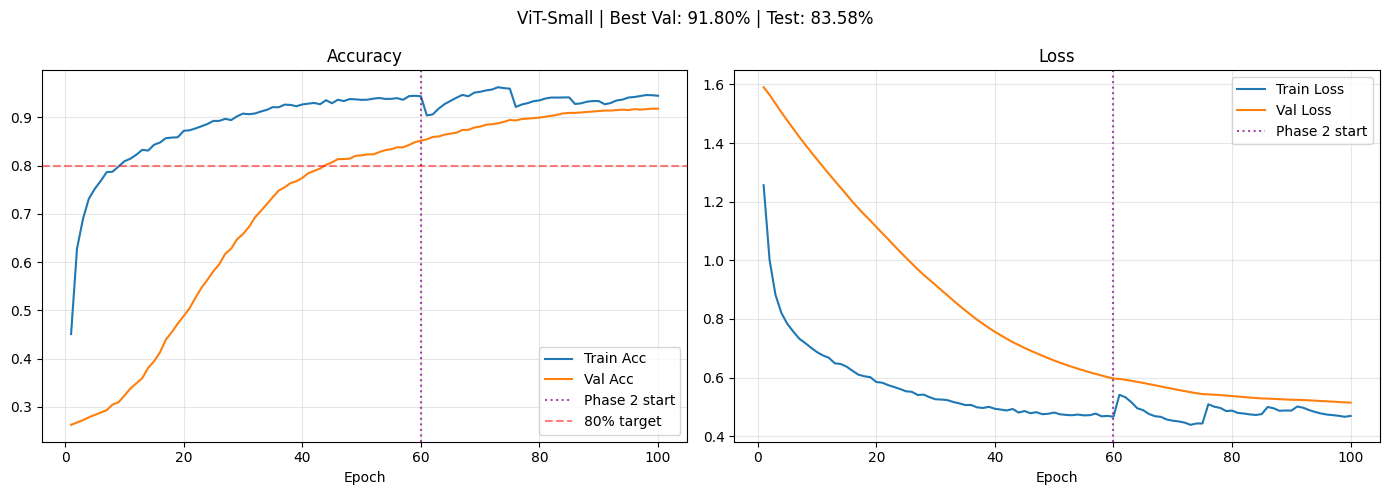

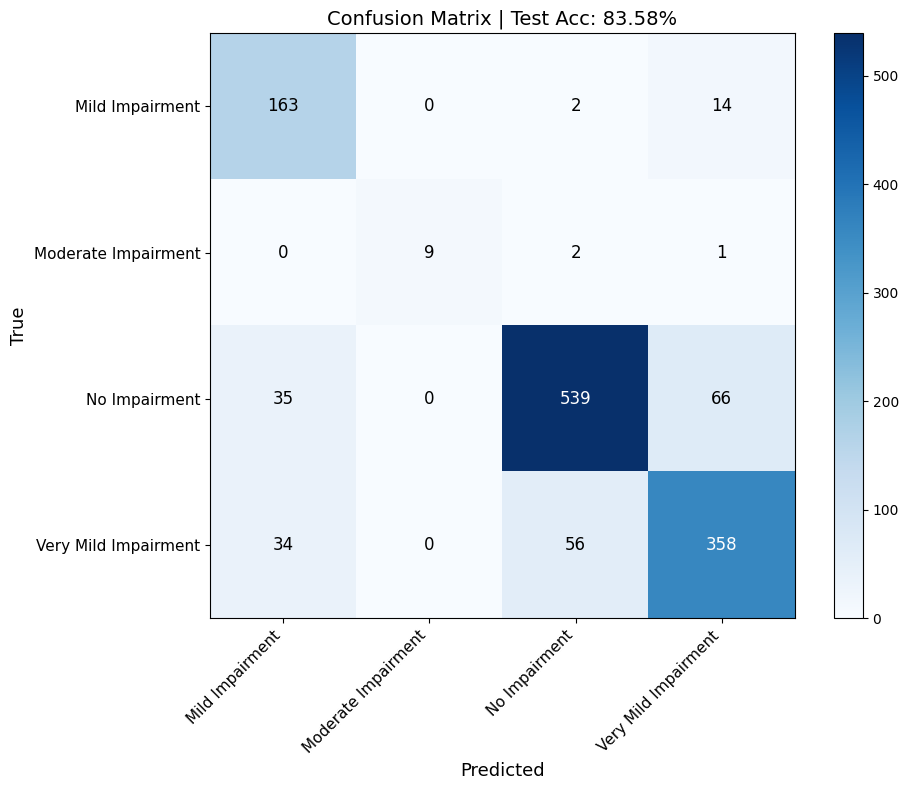

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31344\2253923103.py:94: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):


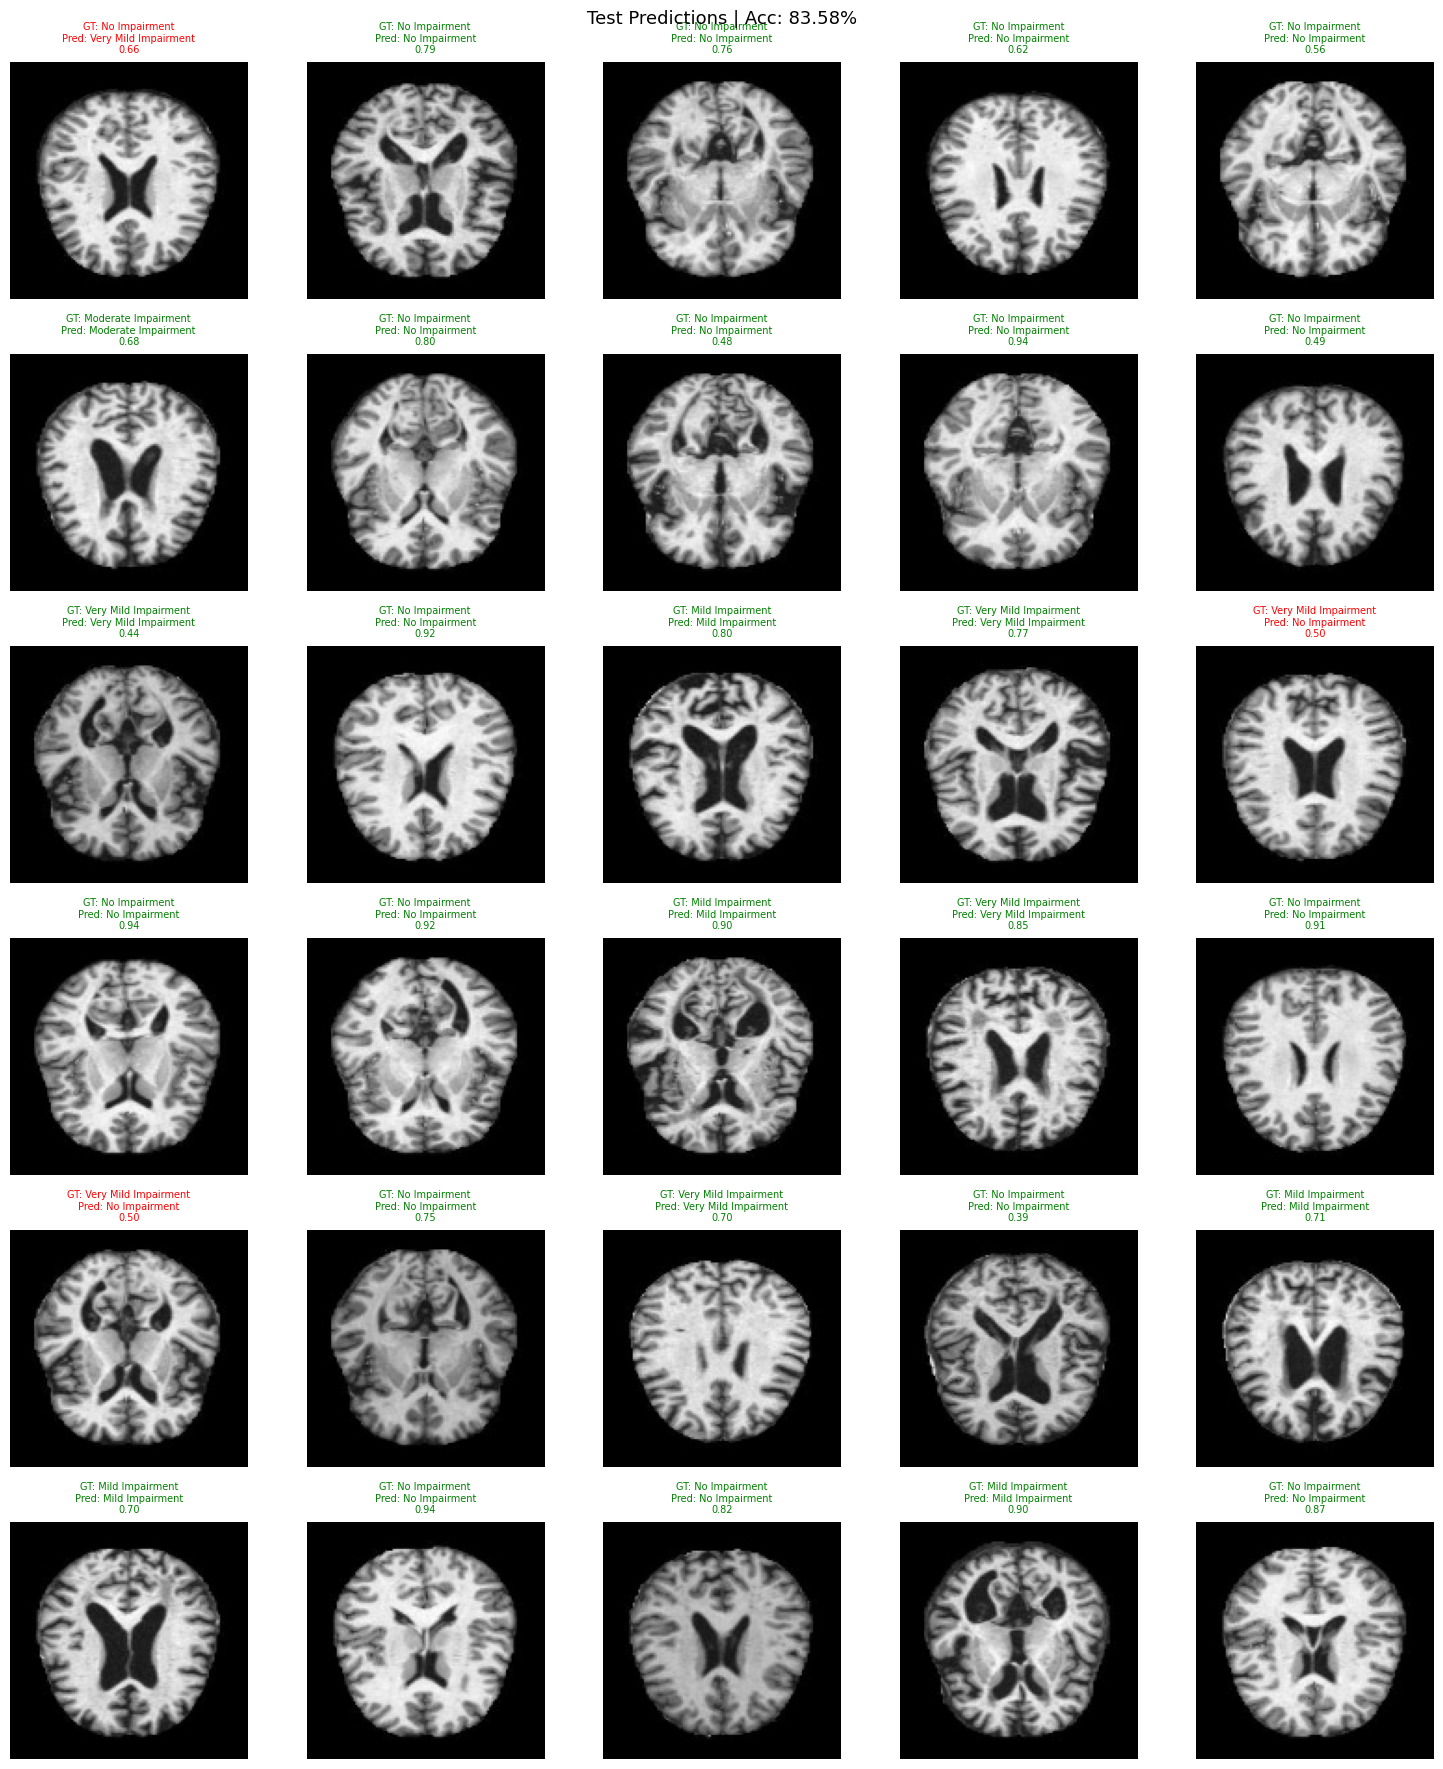

Saved test_predictions.png

All done!


In [46]:
# Average last 5 saved ckpts
if len(saved_ckpts) == 0:
    print("No extra ckpts — loading best_vit.pth directly.")
    best_model = build_model(pretrained=False)
    best_model.load_state_dict(torch.load(config.BEST_CKPT, map_location=config.DEVICE, weights_only=True))
else:
    print(f"Averaging {len(saved_ckpts)} checkpoint(s) ...")
    avg_state = {
        k: sum(c[k].float() for c in saved_ckpts) / len(saved_ckpts)
        for k in saved_ckpts[0]
    }
    torch.save(avg_state, config.AVG_CKPT)
    best_model = build_model(pretrained=False)
    best_model.load_state_dict(torch.load(config.AVG_CKPT, map_location=config.DEVICE, weights_only=True))

best_model = best_model.to(config.DEVICE)
best_model.eval()

# Eval
def evaluate(m, loader):
    m.eval()
    correct = total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(config.DEVICE, non_blocking=True)
            labels = labels.to(config.DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):
                preds = m(images).argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return correct / total, all_preds, all_labels

test_acc, test_preds, test_labels = evaluate(best_model, test_loader)
print(f"\n{'='*50}")
print(f"  Overall Test Accuracy : {test_acc * 100:.2f}%")
print(f"{'='*50}")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Training curves
phase1_epochs = 60  # from your logs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history["tr_acc"]) + 1)

ax1.plot(epochs_range, history["tr_acc"], label="Train Acc")
ax1.plot(epochs_range, history["vl_acc"], label="Val Acc")
ax1.axvline(x=phase1_epochs, color="purple", linestyle=":", alpha=0.7, label="Phase 2 start")
ax1.axhline(y=0.80, color="r", linestyle="--", alpha=0.5, label="80% target")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["tr_loss"], label="Train Loss")
ax2.plot(epochs_range, history["vl_loss"], label="Val Loss")
ax2.axvline(x=phase1_epochs, color="purple", linestyle=":", alpha=0.7, label="Phase 2 start")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f"ViT-Small | Best Val: {best_val_acc*100:.2f}% | Test: {test_acc*100:.2f}%")
plt.tight_layout(); plt.savefig("training_curves.png", dpi=100); plt.show()

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues"); plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=11)
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=11)
ax.set_xlabel("Predicted", fontsize=13); ax.set_ylabel("True", fontsize=13)
ax.set_title(f"Confusion Matrix | Test Acc: {test_acc*100:.2f}%", fontsize=14)
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=100); plt.show()

# Sample predictions
_tf = transforms.Compose([
    GrayscaleToRGB(),
    transforms.Resize((config.INPUT_SIZE, config.INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.MEAN, std=config.STD),
])

def plot_predictions(num_images=30):
    img_paths = (list(config.TEST_DIR.rglob("*.jpg")) +
                 list(config.TEST_DIR.rglob("*.jpeg")) +
                 list(config.TEST_DIR.rglob("*.png")))
    sample = random.sample(img_paths, min(num_images, len(img_paths)))
    cols = 5; rows = math.ceil(len(sample) / cols)
    plt.figure(figsize=(15, rows * 3))
    for i, p in enumerate(sample):
        img    = Image.open(p).convert("RGB")
        tensor = _tf(Image.open(p)).unsqueeze(0).to(config.DEVICE)
        with torch.inference_mode():
            with torch.cuda.amp.autocast(enabled=(config.DEVICE == "cuda")):
                probs = torch.softmax(best_model(tensor), dim=1)
        pred_idx  = probs.argmax(1).item()
        pred_prob = probs.max().item()
        gt        = Path(p).parent.name
        color     = "green" if class_names[pred_idx] == gt else "red"
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"GT: {gt}\nPred: {class_names[pred_idx]}\n{pred_prob:.2f}", fontsize=7, color=color)
        plt.axis("off")
    plt.suptitle(f"Test Predictions | Acc: {test_acc*100:.2f}%", fontsize=13)
    plt.tight_layout(); plt.savefig("test_predictions.png", dpi=100); plt.show()
    print("Saved test_predictions.png")

plot_predictions()
print("\nAll done!")